In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, roc_curve, roc_auc_score)

In [24]:
data = pd.read_csv("pima-indians-diabetes.data.csv")

data.columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                'Insulin','BMI','DiabetesPedigree','Age','Outcome']

In [25]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
models = {
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}

In [29]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)

    results[name] = {
        'model': model,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'cm': cm,
        'fpr': fpr,
        'tpr': tpr,
        'auc': auc_val
    }

In [30]:
for name, res in results.items():
    print(f"\n--- {name} ---")
    print(f"Accuracy  : {res['accuracy']:.4f}")
    print(f"Precision : {res['precision']:.4f}")
    print(f"Recall    : {res['recall']:.4f}")
    print(f"F1 Score  : {res['f1']:.4f}")
    print(f"AUC       : {res['auc']:.4f}")
    print("Confusion Matrix:\n", res['cm'])


--- SVM (RBF) ---
Accuracy  : 0.7188
Precision : 0.6140
Recall    : 0.5224
F1 Score  : 0.5645
AUC       : 0.8021
Confusion Matrix:
 [[103  22]
 [ 32  35]]

--- Naive Bayes ---
Accuracy  : 0.7135
Precision : 0.5882
Recall    : 0.5970
F1 Score  : 0.5926
AUC       : 0.7871
Confusion Matrix:
 [[97 28]
 [27 40]]

--- Decision Tree ---
Accuracy  : 0.7083
Precision : 0.5932
Recall    : 0.5224
F1 Score  : 0.5556
AUC       : 0.6652
Confusion Matrix:
 [[101  24]
 [ 32  35]]

--- KNN ---
Accuracy  : 0.7344
Precision : 0.6333
Recall    : 0.5672
F1 Score  : 0.5984
AUC       : 0.7845
Confusion Matrix:
 [[103  22]
 [ 29  38]]


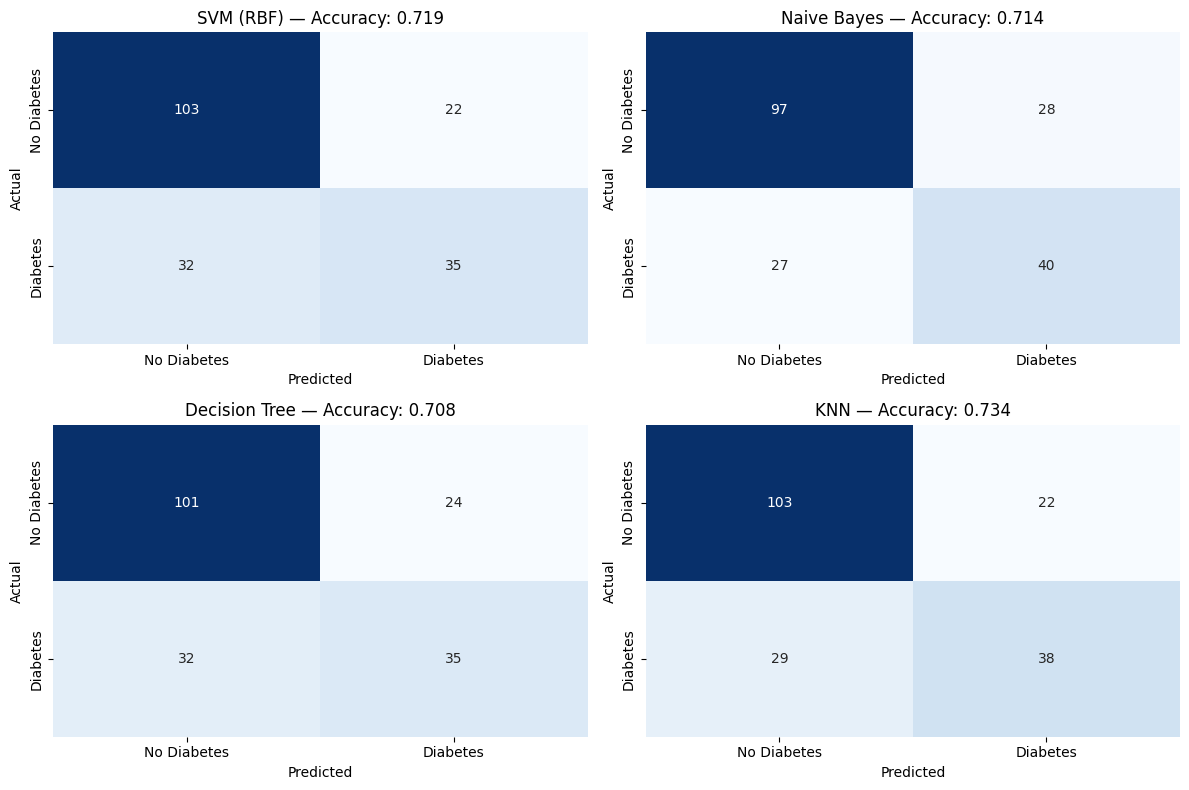

In [31]:
plt.figure(figsize=(12, 8))
for i, (name, res) in enumerate(results.items(), 1):
    ax = plt.subplot(2, 2, i)
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Diabetes','Diabetes'], yticklabels=['No Diabetes','Diabetes'])
    ax.set_title(f"{name} — Accuracy: {res['accuracy']:.3f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

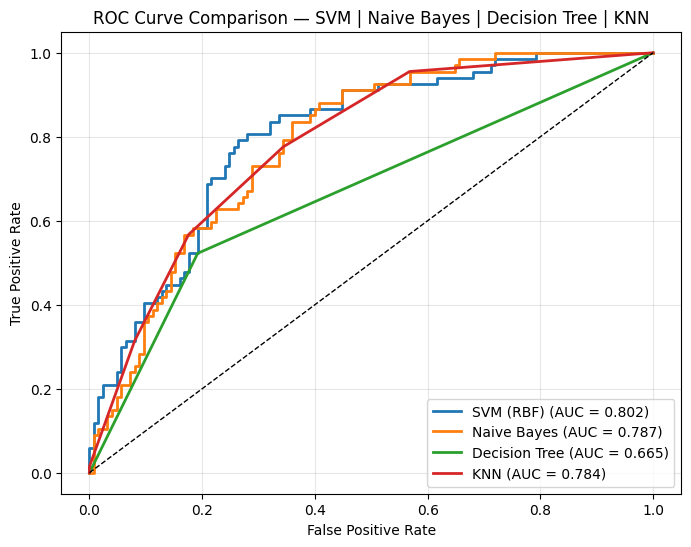

In [32]:
plt.figure(figsize=(8, 6))
for name, res in results.items():
    plt.plot(res['fpr'], res['tpr'], lw=2, label=f"{name} (AUC = {res['auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — SVM | Naive Bayes | Decision Tree | KNN")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [33]:
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [res['accuracy'] for res in results.values()],
    'Precision': [res['precision'] for res in results.values()],
    'Recall': [res['recall'] for res in results.values()],
    'F1 Score': [res['f1'] for res in results.values()],
    'AUC': [res['auc'] for res in results.values()]
})
print("\n📊 Model Comparison Summary:")
print(summary)


📊 Model Comparison Summary:
           Model  Accuracy  Precision    Recall  F1 Score       AUC
0      SVM (RBF)  0.718750   0.614035  0.522388  0.564516  0.802149
1    Naive Bayes  0.713542   0.588235  0.597015  0.592593  0.787104
2  Decision Tree  0.708333   0.593220  0.522388  0.555556  0.665194
3            KNN  0.734375   0.633333  0.567164  0.598425  0.784478
